# Objects, nearest nodes, and graph projection

This notebook shows how to match external objects to a graph and how to project them onto nearest graph edges.


In [1]:
# To install IduEdu in a clean environment:
# !pip install IduEdu

OSM_ID = 1114252


In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import LineString, Point

from iduedu import get_drive_graph

G = get_drive_graph(osm_id=OSM_ID, simplify=True, keep_largest_subgraph=True)
G


2026-07-07 15:18:36.038 | WARNING  | Removing 38 nodes outside the largest strongly connected component. Retaining 707 of 745 nodes.


UrbanGraph(nodes=707, edges=1188, is_multigraph=True, is_directed=True, edge_direction_column='oneway', crs='EPSG:32636', type='drive')

## Create simulated objects near roads

The example below creates a small synthetic object layer. We take several road segments, place points on them, and then shift those points perpendicular to the road. This imitates buildings or services located near, but not directly on, the road centerline.


In [3]:
def line_perpendicular_offset_point(line, fraction=0.5, distance=18.0, side=1):
    # Return a point shifted perpendicular to a line for visual test objects.
    point = line.interpolate(fraction, normalized=True)
    distance_along = line.project(point)
    eps = max(min(line.length * 0.03, 8.0), 1.0)
    before = line.interpolate(max(distance_along - eps, 0.0))
    after = line.interpolate(min(distance_along + eps, line.length))

    dx = after.x - before.x
    dy = after.y - before.y
    norm = float(np.hypot(dx, dy))
    if norm == 0:
        return point

    return Point(
        point.x + side * (-dy / norm) * distance,
        point.y + side * (dx / norm) * distance,
    )


def make_focus_area(graph, radius=250):
    # Choose a compact road-rich area near the graph center.
    graph_center = graph.nodes_gdf.geometry.union_all().centroid
    candidate_edges = graph.edges_gdf.loc[graph.edges_gdf.geometry.length > 45].copy()
    seed_idx = candidate_edges.distance(graph_center).sort_values().index[0]
    seed_point = candidate_edges.loc[seed_idx, "geometry"].interpolate(0.5, normalized=True)
    return seed_point.buffer(radius)


def make_simulated_objects(graph, focus_area, count=10, offset_m=50.0):
    # Create simulated point objects near roads inside the focus area.
    # The offset is intentionally visible so projection links are readable.
    local_edges = graph.edges_gdf.loc[graph.edges_gdf.intersects(focus_area)].copy()
    local_edges = local_edges.sort_values("length_meter", ascending=False).head(count)

    records = []
    for i, (_, edge) in enumerate(local_edges.iterrows()):
        fraction = 0.35 + 0.08 * (i % 4)
        point = line_perpendicular_offset_point(
            edge.geometry,
            fraction=fraction,
            distance=offset_m,
        )
        records.append({"object_id": i, "name": f"simulated_object_{i}", "geometry": point})

    objects_gdf = gpd.GeoDataFrame(records, geometry="geometry", crs=graph.crs).set_index("object_id")
    return objects_gdf


focus_area = make_focus_area(G)
objects = make_simulated_objects(G, focus_area)
objects


,name,geometry
object_id,,
0,simulated_object_0,POINT (345913.384 6647966.294)
1,simulated_object_1,POINT (345917.793 6648147.475)
2,simulated_object_2,POINT (346510.261 6647723.356)
3,simulated_object_3,POINT (346670.891 6648135.006)
4,simulated_object_4,POINT (346739.248 6648065.285)
5,simulated_object_5,POINT (346177.284 6647609.472)
6,simulated_object_6,POINT (346279.455 6647827.652)
7,simulated_object_7,POINT (346273.338 6647927.625)
8,simulated_object_8,POINT (345970.905 6647802.258)


In [4]:
def bounds_around_layers(*layers, margin=80):
    # Return padded bounds around non-empty GeoDataFrames or GeoSeries.
    bounds = []
    for layer in layers:
        if layer is None or len(layer) == 0:
            continue
        bounds.append(layer.total_bounds)
    minx = min(b[0] for b in bounds) - margin
    miny = min(b[1] for b in bounds) - margin
    maxx = max(b[2] for b in bounds) + margin
    maxy = max(b[3] for b in bounds) + margin
    return minx, miny, maxx, maxy


def roads_around_objects(graph, objects_gdf, padding=220):
    # Select only roads and nodes near the example objects for readable plots.
    plot_area = objects_gdf.geometry.union_all().convex_hull.buffer(padding)
    roads = graph.edges_gdf.loc[graph.edges_gdf.intersects(plot_area)].copy()
    nodes = graph.nodes_gdf.loc[graph.nodes_gdf.intersects(plot_area)].copy()
    return plot_area, roads, nodes


def set_plot_window(ax, *layers, margin=80):
    minx, miny, maxx, maxy = bounds_around_layers(*layers, margin=margin)
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.set_aspect("equal", adjustable="box")
    ax.set_axis_off()


plot_area, local_roads, local_nodes = roads_around_objects(G, objects)
print("local roads:", len(local_roads))
print("local nodes:", len(local_nodes))


local roads: 29
local nodes: 14


## Nearest graph nodes

`nearest_nodes` maps each object geometry to the nearest existing graph node. This is fast and useful for coarse object-to-graph matching, but it does not change graph topology.


In [5]:
from iduedu import nearest_nodes

objects["nearest_node"] = nearest_nodes(G, objects)
objects[["name", "nearest_node"]]


,name,nearest_node
object_id,,
0,simulated_object_0,727
1,simulated_object_1,727
2,simulated_object_2,367
3,simulated_object_3,392
4,simulated_object_4,393
5,simulated_object_5,326
6,simulated_object_6,326
7,simulated_object_7,366
8,simulated_object_8,306


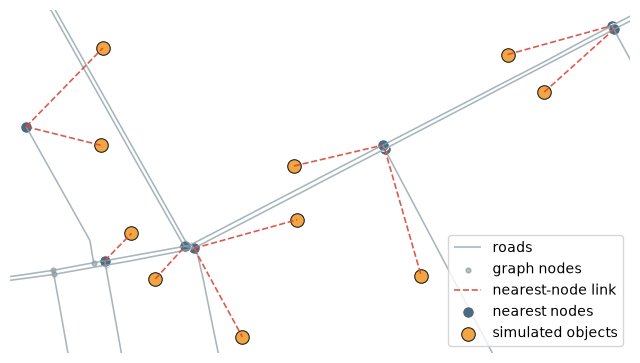

In [6]:
nearest_node_geoms = G.nodes_gdf.loc[objects["nearest_node"], "geometry"]
nearest_lines = gpd.GeoDataFrame(
    geometry=[LineString([object_point, node_point]) for object_point, node_point in zip(objects.geometry, nearest_node_geoms)],
    crs=G.crs,
)

fig, ax = plt.subplots(figsize=(8, 8))
local_roads.plot(ax=ax, color="#8FA1AB", linewidth=1.15, alpha=0.78, label="roads")
local_nodes.plot(ax=ax, color="#7E8A92", markersize=12, alpha=0.55, label="graph nodes")
nearest_lines.plot(ax=ax, color="#D84A3A", linewidth=1.2, linestyle="--", alpha=0.9, label="nearest-node link")
nearest_node_geoms.plot(ax=ax, color="#496A81", markersize=70, edgecolor="white", linewidth=0.8, label="nearest nodes")
objects.plot(ax=ax, color="#F2A541", markersize=95, edgecolor="#222222", linewidth=0.8, label="simulated objects")
set_plot_window(ax, objects, nearest_node_geoms, margin=30)
ax.legend(loc="lower right", frameon=True)
plt.show()


## Project objects with link edges

`project_objects2urban_graph` splits nearest edges when needed and prepares changes that can be applied later. With `add_link_edge=True`, every object receives its own object node and a connector edge to the projected point on the graph.


In [7]:
from iduedu import apply_urban_graph_changes, project_objects2urban_graph

WALK_SPEED_M_PER_MIN = 5 * 1000 / 60

changes_with_links, object2node_with_links = project_objects2urban_graph(
    G,
    objects,
    WALK_SPEED_M_PER_MIN,
    add_link_edge=True,
)
G_with_objects = apply_urban_graph_changes(G, changes_with_links)

print(object2node_with_links.head())
print("new nodes:", 0 if changes_with_links.nodes_gdf is None else len(changes_with_links.nodes_gdf))
print("new edges:", 0 if changes_with_links.edges_gdf is None else len(changes_with_links.edges_gdf))
print("deleted source edges:", 0 if changes_with_links.edges_to_delete is None else len(changes_with_links.edges_to_delete))


object_index
0    751
1    752
2    753
3    754
4    755
Name: node_id, dtype: int64
new nodes: 20
new edges: 30
deleted source edges: 10


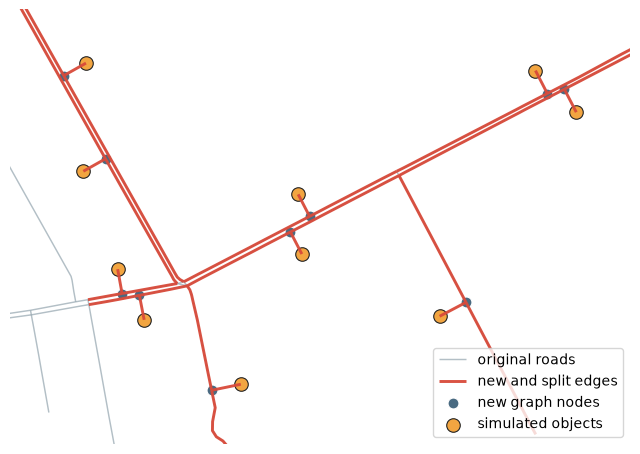

In [8]:
new_nodes_with_links = changes_with_links.nodes_gdf
new_edges_with_links = changes_with_links.edges_gdf

fig, ax = plt.subplots(figsize=(8, 8))
local_roads.plot(ax=ax, color="#8FA1AB", linewidth=1.05, alpha=0.68, label="original roads")
if new_edges_with_links is not None:
    new_edges_with_links.plot(ax=ax, color="#D84A3A", linewidth=2.1, alpha=0.95, label="new and split edges")
if new_nodes_with_links is not None:
    new_nodes_with_links.plot(ax=ax, color="#496A81", markersize=62, edgecolor="white", linewidth=0.8, label="new graph nodes")
objects.plot(ax=ax, color="#F2A541", markersize=95, edgecolor="#222222", linewidth=0.8, label="simulated objects")
set_plot_window(ax, objects, new_nodes_with_links, margin=90)
ax.legend(loc="lower right", frameon=True)
plt.show()


## Project objects without link edges

With `add_link_edge=False`, objects are mapped to projection nodes on the graph. The graph still receives split edges and projection nodes, but there are no separate object-to-road connector edges.


In [9]:
changes_without_links, object2node_without_links = project_objects2urban_graph(
    G,
    objects,
    WALK_SPEED_M_PER_MIN,
    add_link_edge=False,
)
G_projected = apply_urban_graph_changes(G, changes_without_links)

print(object2node_without_links.head())
print("new nodes:", 0 if changes_without_links.nodes_gdf is None else len(changes_without_links.nodes_gdf))
print("new edges:", 0 if changes_without_links.edges_gdf is None else len(changes_without_links.edges_gdf))


object_index
0    741
1    742
2    743
3    744
4    745
Name: node_id, dtype: int64
new nodes: 10
new edges: 20


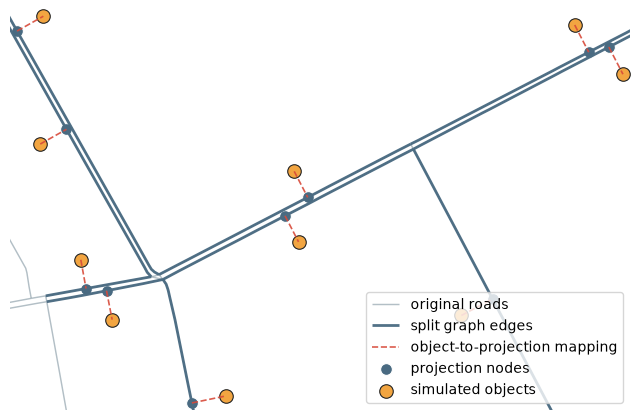

In [10]:
projection_nodes = G_projected.nodes_gdf.loc[object2node_without_links]
projection_lines = gpd.GeoDataFrame(
    geometry=[LineString([object_point, node_point]) for object_point, node_point in zip(objects.geometry, projection_nodes.geometry)],
    crs=G.crs,
)

fig, ax = plt.subplots(figsize=(8, 8))
local_roads.plot(ax=ax, color="#8FA1AB", linewidth=1.05, alpha=0.68, label="original roads")
if changes_without_links.edges_gdf is not None:
    changes_without_links.edges_gdf.plot(ax=ax, color="#496A81", linewidth=2.0, alpha=0.95, label="split graph edges")
projection_lines.plot(ax=ax, color="#D84A3A", linewidth=1.2, linestyle="--", alpha=0.9, label="object-to-projection mapping")
projection_nodes.plot(ax=ax, color="#496A81", markersize=72, edgecolor="white", linewidth=0.8, label="projection nodes")
objects.plot(ax=ax, color="#F2A541", markersize=95, edgecolor="#222222", linewidth=0.8, label="simulated objects")
set_plot_window(ax, objects, projection_nodes, margin=10)
ax.legend(loc="lower right", frameon=True)
plt.show()


## Method form

For in-memory workflows, `UrbanGraph.project_objects` applies the changes and returns the updated graph plus the object-to-node mapping.


In [11]:
G_method, object2node_method = G.project_objects(
    objects,
    WALK_SPEED_M_PER_MIN,
    max_dist=250,
    add_link_edge=True,
)

G_method, object2node_method.head()


(UrbanGraph(nodes=727, edges=1208, is_multigraph=True, is_directed=True, edge_direction_column='oneway', crs='EPSG:32636', type='drive'),
 object_index
 0    751
 1    752
 2    753
 3    754
 4    755
 Name: node_id, dtype: int64)